In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib ipympl

In [2]:
# CREATE A FILE OF PLAYS FOR SELECTED YEARS

Season = ['2022', '2023', '2024', '2025']

plays_loop = []

for season in Season:
    plays = pd.read_csv(f"{season}plays.csv", low_memory = False)
    plays['Season'] = season
    plays_loop.append(plays)

plays_all = pd.concat(plays_loop, ignore_index=True)
plays_all.loc[plays_all['batteam'] == 'OAK', 'batteam'] = 'ATH'

In [3]:
# CREATION OF VARIABLES FOR USE ELSEWHERE

# Remove events that are NP (no play) or where the plate appearance was continued (pa = 0) or playoff games
plays_all = plays_all[plays_all['event'] != 'NP']
plays_all = plays_all[plays_all['pa'] != 0]
plays_all = plays_all[plays_all['gametype'] == 'regular']

# Fill in blank for not pitch data
plays_all['pitches'] = plays_all['pitches'].fillna('')

# Compute number of outs for the event
plays_all['outs_event'] = plays_all['outs_post'] - plays_all['outs_pre']

# Determine if there is a positive ab (no_outs, SF or SH)
plays_all['no_outs'] = (plays_all['outs_post'] == plays_all['outs_pre']).astype(int)
plays_all['sacrifice'] = ((plays_all['sh'] == 1) | (plays_all['sf'] == 1)).astype(int)
plays_all['positive_ab'] = ((plays_all['no_outs'] == 1) | (plays_all['sacrifice'] == 1) | (plays_all['runs'] >= 1)).astype(int)

# Define whether there were and bunt attempts that resulted in a strike
plays_all['bunt_strike'] = 0
plays_all.loc[(plays_all.pitches.str.contains("L|M|O", na=False)), 'bunt_strike'] = 1

# Count the number of unsucessful bunt attempts
plays_all['bunt_strike_count'] = 0
plays_all['bunt_strike_count'] = plays_all['pitches'].str.count(r"[LMO]") 

# Count the number of bunt attempts
plays_all['bunt_attempts'] = plays_all['bunt'] + plays_all['bunt_strike_count']
plays_all['bunt_attempted'] = 0

# Dichotomous variable for whether a bunt was attempted
plays_all.loc[plays_all['bunt_attempts'] >= 1, 'bunt_attempted'] = 1

# Count the number of swings including bunts
plays_all['swings_all'] = 0
plays_all['swings_all'] = plays_all['pitches'].str.count(r"[FLMOQRSTXY]") 

# Count the number of swings excluding bunt attempts
plays_all['swings'] = 0
plays_all['swings'] = plays_all['swings_all'] - plays_all['bunt_attempts']

# Determine whether a swing attempt was made
plays_all['swing_attempted'] = 0
plays_all.loc[plays_all['swings'] >= 1, 'swing_attempted'] = 1

# Create at-bat category type based on swing/bunt history
plays_all['ab_cat'] = 0 # No attempt to hit the ball made
plays_all.loc[(plays_all['bunt_attempted'] == 0) & (plays_all['swing_attempted'] == 1), 'ab_cat'] = 1 # Swings only
plays_all.loc[(plays_all['bunt_attempted'] == 1) & (plays_all['swing_attempted'] == 0), 'ab_cat'] = 2 # Bunts only
plays_all.loc[(plays_all['bunt_attempted'] == 1) & (plays_all['swing_attempted'] == 1), 'ab_cat'] = 3 # Mixed (swings and bunts)

# Combine/collapse line-up positions
plays_all['lp_cat'] = pd.cut(plays_all['lp'], bins=[0, 3, 6, 8, 9], labels=[1, 4, 7, 9], right=True).astype(int)

# Combine/collapse innings
plays_all['inning_cat'] = pd.cut(plays_all['inning'], bins=[0, 6, 7, 8, float('inf')], labels=[1, 7, 8, 9], right=True).astype(int)

# Define baserunner situation(s)
plays_all['runner_first'] = plays_all['br1_pre'].notna().astype(int)
plays_all['runner_second'] = plays_all['br2_pre'].notna().astype(int)
plays_all['runner_third'] = plays_all['br3_pre'].notna().astype(int)
plays_all['runners'] = (plays_all['runner_first'].astype(str) + plays_all['runner_second'].astype(str) + 
                        plays_all['runner_third'].astype(str))

plays_all['runners_cat'] = 5 # Any runner on third
plays_all.loc[plays_all['runners'] == '000', 'runners_cat'] = 1
plays_all.loc[plays_all['runners'] == '100', 'runners_cat'] = 2
plays_all.loc[plays_all['runners'] == '010', 'runners_cat'] = 3
plays_all.loc[plays_all['runners'] == '110', 'runners_cat'] = 4

# Define whether it was (or wasn't) a sacrifice opportunity
plays_all['sacrifice_opportunity'] = 1
plays_all.loc[(plays_all['runners'] == '000') | (plays_all['outs_pre'] == 2), 'sacrifice_opportunity'] = 0

# Define score based on whether batting or pitching
plays_all['score_batting'] = np.where(plays_all['vis_home'] == 0, plays_all['score_v'], plays_all['score_h'])
plays_all['score_pitching'] = np.where(plays_all['vis_home'] == 0, plays_all['score_h'], plays_all['score_v'])
plays_all['score_difference'] = (plays_all['score_batting'] - plays_all['score_pitching']).clip(lower=-2, upper=2)

In [4]:
# SUBSETS CONTAINING BUNT ATTEMPTS

bunt_attempted = plays_all[plays_all['bunt_attempted'] == 1]
bunt0 = bunt_attempted[bunt_attempted['bunt'] == 0] # Failed bunting attempts
bunt1 = bunt_attempted[bunt_attempted['bunt'] == 1] # Successful bunting attempts

bunt_attempted_nonsac = bunt_attempted[bunt_attempted['sacrifice_opportunity'] == 0]
bunt_attempted_sacopp = bunt_attempted[bunt_attempted['sacrifice_opportunity'] == 1]
bunt_nonsac = bunt1[bunt1['sacrifice_opportunity'] == 0]
bunt_sacopp = bunt1[bunt1['sacrifice_opportunity'] == 1]

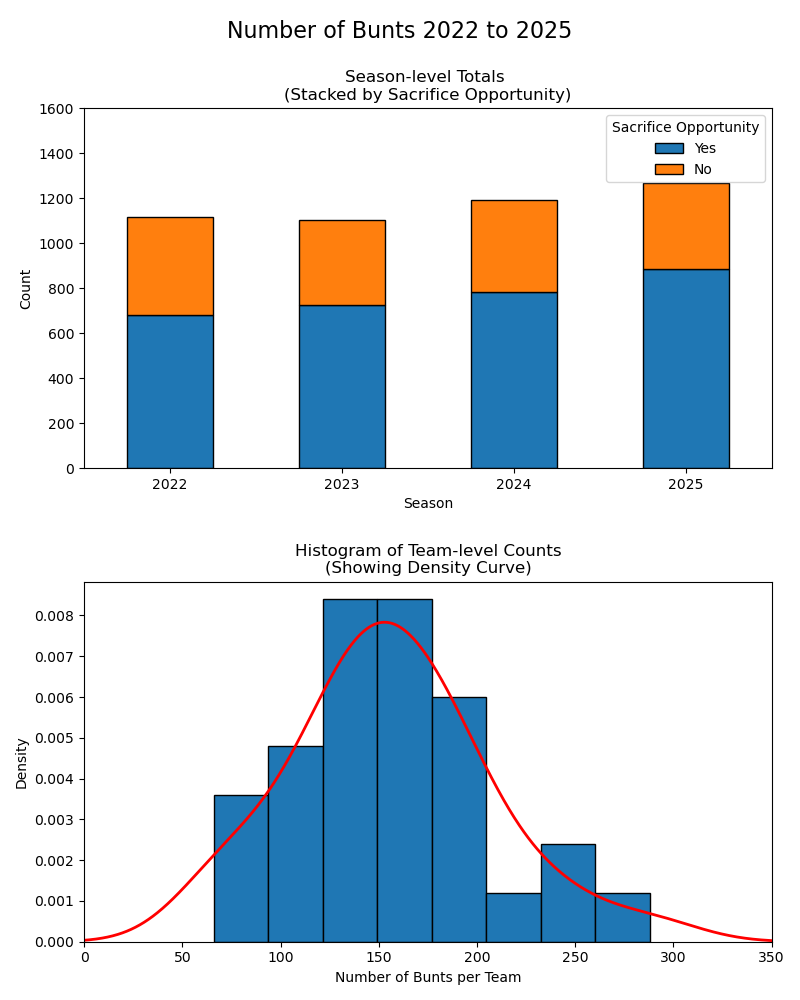

In [5]:
# PLOTS USING THE BUNT FILES

season_sac_counts = bunt1.groupby(['Season', 'sacrifice_opportunity']).size().unstack(fill_value=0)
season_sac_counts = season_sac_counts[[1, 0]]

fig, axes = plt.subplots(2, 1, figsize = (8,10))

season_sac_counts.plot(kind = 'bar', stacked = True, edgecolor = 'black', ax = axes[0])
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Count")
axes[0].set_title("\nSeason-level Totals \n(Stacked by Sacrifice Opportunity)")
axes[0].tick_params(axis = 'x', rotation = 0)
axes[0].set_ylim(0, 1600)
axes[0].legend(title = 'Sacrifice Opportunity', labels = ["Yes", "No"])

team_bunt_count = bunt1.groupby("batteam").size()
axes[1].hist(team_bunt_count, bins = 8, edgecolor = 'black', label = 'Histogram', density = True)
team_bunt_count.plot(kind = 'kde', color = 'red', linewidth = 2, label = 'Density', ax = axes[1])
axes[1].set_xlabel("Number of Bunts per Team")
axes[1].set_ylabel("Density")
axes[1].set_title("\nHistogram of Team-level Counts\n(Showing Density Curve)")
axes[1].set_xlim(0, 350)

fig.suptitle('Number of Bunts 2022 to 2025', fontsize = 16);

plt.tight_layout()
plt.savefig("num_bunts_2022to2025.png", dpi = 300, bbox_inches = 'tight');

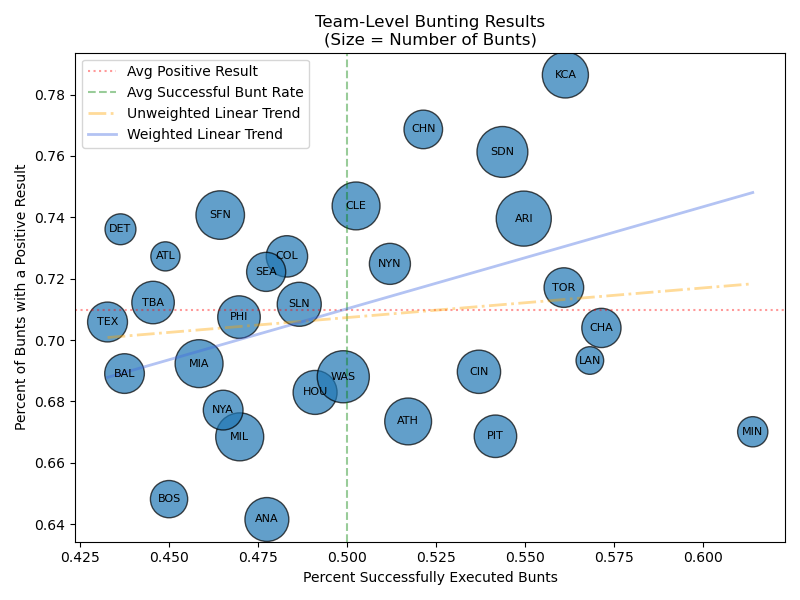

In [6]:
# TEAM SCATTERPLOT

# Percent successful bunt attempts (by team)
pct_bunt = bunt_attempted.groupby("batteam")["bunt"].mean().reset_index(name = "pct_bunt")

# Percent positive result - from successful bunt attempts (by team)
pct_positive = bunt1.groupby("batteam")["positive_ab"].mean().reset_index(name = "pct_positive")

# Create size variable based on total bunt attempts
counts = bunt_attempted.groupby("batteam").size().reset_index(name = "count")

# Merge into single file
team_stats = pct_bunt.merge(pct_positive, on = "batteam").merge(counts, on = "batteam")

plt.figure(figsize = (8, 6))

# Scatterplot (bubble size = count)
plt.scatter(team_stats["pct_bunt"], team_stats["pct_positive"], s = team_stats["count"] * 3, alpha = 0.7, edgecolor = 'black')

# League averages
overall_bunt = bunt_attempted["bunt"].mean()
overall_positive = bunt1["positive_ab"].mean()

plt.axhline(overall_positive, color = 'red', linestyle = ':', alpha = 0.4, label = 'Avg Positive Result')

plt.axvline(overall_bunt, color = 'green', linestyle = '--', alpha = 0.4, label = 'Avg Successful Bunt Rate')

# Unweighted Regression
m_unw, b_unw = np.polyfit(team_stats["pct_bunt"], team_stats["pct_positive"], 1)

# Weighted regression
m_w, b_w = np.polyfit(team_stats["pct_bunt"], team_stats["pct_positive"], 1, w = team_stats["count"])

# Smooth x values
x_vals = np.linspace(team_stats["pct_bunt"].min(), team_stats["pct_bunt"].max(), 100)

# Predicted y values
y_unw = m_unw * x_vals + b_unw
y_w = m_w * x_vals + b_w

# Plot regression lines
plt.plot(x_vals, y_unw, color = 'orange', linestyle = '-.', alpha = 0.4, linewidth = 2, label = 'Unweighted Linear Trend')

plt.plot(x_vals, y_w, color = 'royalblue', linestyle = '-', alpha = 0.4, linewidth = 2, label = 'Weighted Linear Trend')

# Label points with team name
for _, row in team_stats.iterrows():
    plt.text(row["pct_bunt"], row["pct_positive"], row["batteam"], fontsize = 8, ha = 'center', va = 'center')

plt.xlabel("Percent Successfully Executed Bunts")
plt.ylabel("Percent of Bunts with a Positive Result")
plt.title("Team-Level Bunting Results\n(Size = Number of Bunts)")

plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("scatterplot.png", dpi = 300, bbox_inches = 'tight');

In [7]:
# CREATE INNING AND SCORE INFORMATION

# Define at bat where third out occurs
plays_all['Third_out'] = 0
plays_all.loc[plays_all['outs_post'] == 3, 'Third_out'] = 1

# Define end of game at bat
plays_all['End_of_game'] = 0
plays_all.loc[plays_all.groupby('gid').tail(1).index, 'End_of_game'] = 1

# Define whether a walkoff 
plays_all['walkoff'] = 0
plays_all.loc[(plays_all['End_of_game'] == 1) & (plays_all['outs_post'] != 3), 'walkoff'] = 1

# Define whether the end of a half inning
plays_all['End_of_inning'] = 0
plays_all.loc[(plays_all['Third_out'] == 1) | (plays_all['walkoff'] == 1), 'End_of_inning'] = 1

# Create a data frame with the score at the end of each half inning
Inning_end = plays_all.loc[plays_all['End_of_inning'] == 1, 
    ['gid', 'inning', 'top_bot', 'score_batting']].rename(columns = {'score_batting': 'score_inning_end'})

In [8]:
# FILE AND VARIABLE CREATION

# Add end of inning score
plays_all_final = pd.merge(plays_all, Inning_end, on = ['gid', 'inning', 'top_bot'], how = 'left')

# Compute number and whether any runs were scored after an event
plays_all_final['Number_runs_after_event'] = plays_all_final['score_inning_end'] - plays_all_final['score_batting']
plays_all_final['Any_runs_after_event'] = np.where(plays_all_final['score_batting'] == plays_all_final['score_inning_end'], 0, 1)

# Create files of plate appearances that are/are not sacrifice opportunities 
not_a_sac_opp = plays_all_final[plays_all_final['sacrifice_opportunity'] == 0]
sac_opp = plays_all_final[plays_all_final['sacrifice_opportunity'] == 1]

In [9]:
# SACRIFICE SITUATIONS

sac_opp = plays_all_final[plays_all_final['sacrifice_opportunity']==1].copy()
sac_opp['runners_outs'] = sac_opp['runners_cat'].astype(str) + sac_opp['outs_pre'].astype(str)

summary = sac_opp.groupby(['runners_outs', 'bunt']).agg(mean_number_runs_after_event = ('Number_runs_after_event', 'mean'),
                                                                  mean_any_runs_after_event = ('Any_runs_after_event', 'mean'),
                                                                  std_number_runs_after_event = ('Number_runs_after_event', 'std'),
                                                                  std_any_runs_after_event = ('Any_runs_after_event', 'std'),
                                                                  N_events_with_runs = ('Any_runs_after_event', 'sum'),
                                                                  N_events = ('Any_runs_after_event', 'size')).reset_index()

# Compute standard error
summary['se_number_runs'] = summary['std_number_runs_after_event'] / np.sqrt(summary['N_events'])
summary['se_any_runs'] = summary['std_any_runs_after_event'] / np.sqrt(summary['N_events'])
summary['runners'] = summary['runners_outs'].astype(str).str[0].astype(int)
summary['outs'] = summary['runners_outs'].str[-1].astype(int)

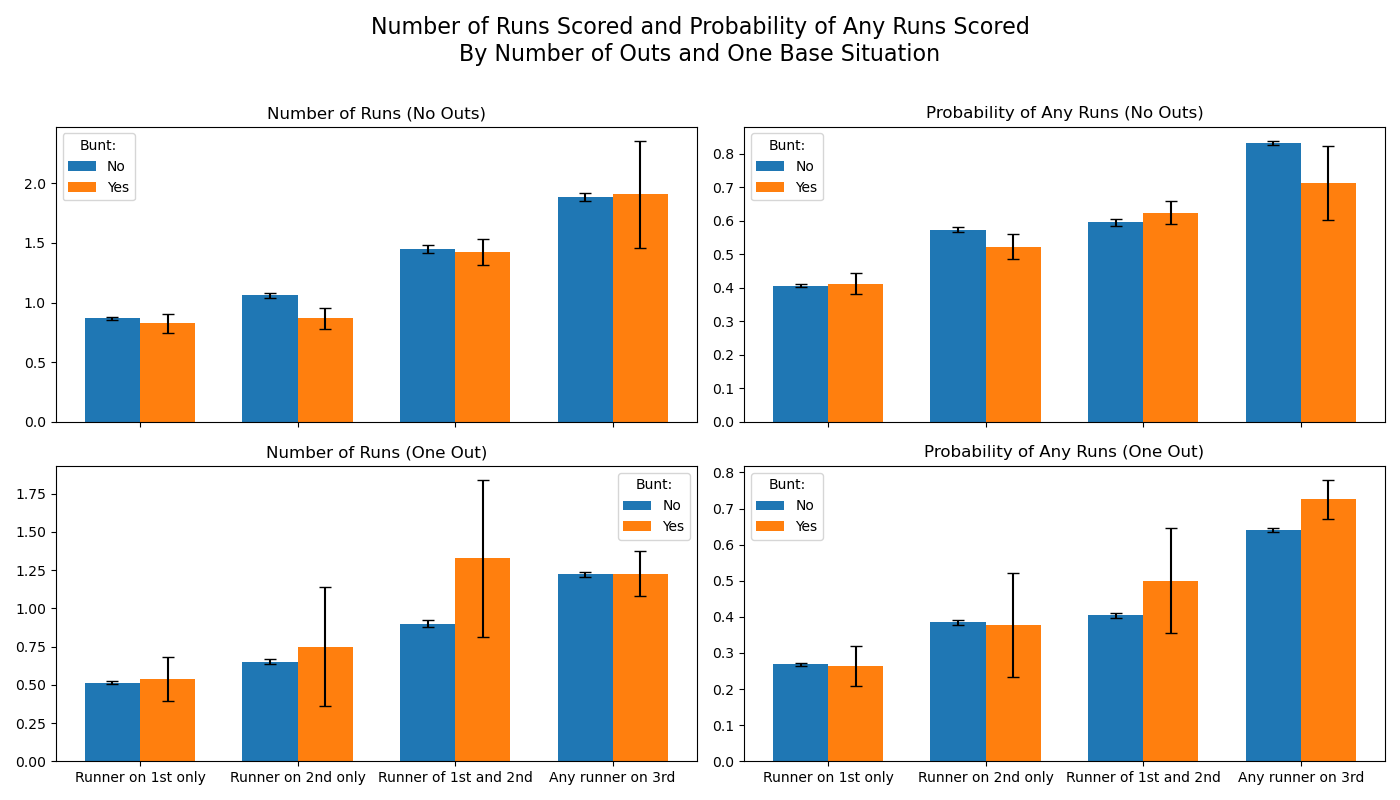

In [10]:
# PLOT NUMBER OF RUNS AND ANY RUNS BY RUNNERS ON BASE AND OUTS

width = 0.35

runners_order = summary['runners'].unique()
x = np.arange(len(runners_order))

custom_labels = ['Runner on 1st only', 'Runner on 2nd only', 'Runner of 1st and 2nd', 'Any runner on 3rd']

outs0 = summary[summary['outs'] == 0]
outs1 = summary[summary['outs'] == 1]

def get_grouped_arrays(data, y_col, se_col):
    
    pivot = data.pivot(index = 'runners', columns = 'bunt', values = [y_col, se_col])

    pivot = pivot.reindex(runners_order)
    
    y0 = pivot[y_col].get(0, pd.Series(0, index = runners_order))
    y1 = pivot[y_col].get(1, pd.Series(0, index = runners_order))
    
    yerr0 = 1.96 * pivot[se_col].get(0, pd.Series(0, index = runners_order))
    yerr1 = 1.96 * pivot[se_col].get(1, pd.Series(0, index = runners_order))
    
    return y0.values, y1.values, yerr0.values, yerr1.values

fig, axes = plt.subplots(2, 2, figsize = (14,8), sharex = True)

def plot_row(ax, data, y_col, se_col, title, colors = ['#1f77b4', '#ff7f0e']):
    y0, y1, yerr0, yerr1 = get_grouped_arrays(data, y_col, se_col)
    ax.bar(x - width/2, y0, width, yerr = yerr0, capsize = 4, color = colors[0], label = 'Bunt = 0')
    ax.bar(x + width/2, y1, width, yerr = yerr1, capsize = 4, color = colors[1], label = 'Bunt = 1')
    ax.set_xticks(x)
    ax.set_xticklabels(custom_labels)
    ax.set_title(title)
    ax.legend(title = 'Bunt:', labels = ['No', 'Yes'])

plot_row(axes[0,0], outs0, 'mean_number_runs_after_event', 'se_number_runs', 'Number of Runs (No Outs)')
plot_row(axes[0,1], outs0, 'mean_any_runs_after_event', 'se_any_runs', 'Probability of Any Runs (No Outs)')

plot_row(axes[1,0], outs1, 'mean_number_runs_after_event', 'se_number_runs', 'Number of Runs (One Out)')
plot_row(axes[1,1], outs1, 'mean_any_runs_after_event', 'se_any_runs', 'Probability of Any Runs (One Out)')

fig.suptitle('Number of Runs Scored and Probability of Any Runs Scored\nBy Number of Outs and One Base Situation\n', fontsize = 16);

plt.tight_layout()

plt.savefig("Num_Any_2022to2025.png", dpi = 300, bbox_inches = 'tight');

In [11]:
# TABLE OF SITUATIONS AND OUTS SHOWING PLAY RESULT

bunts = plays_all_final[plays_all_final['bunt'] == 1].copy()
bunts['bunt_result'] = 0 # Out: No sacrifice
bunts.loc[(bunts['no_outs'] == 0) & (bunts['sacrifice'] == 1), 'bunt_result'] = 1 # Out: Sacrifice 
bunts.loc[bunts['no_outs'] == 1, 'bunt_result'] = 2 # No out 

bunts_runners1 = bunts[bunts['runners_cat'] == 1]
bunts_runners2 = bunts[bunts['runners_cat'] == 2]
bunts_runners3 = bunts[bunts['runners_cat'] == 3]
bunts_runners4 = bunts[bunts['runners_cat'] == 4]
bunts_runners5 = bunts[bunts['runners_cat'] == 5]

cross1 = pd.crosstab(index=[bunts_runners1['runners_cat'], bunts_runners1['bunt_result']], columns=bunts_runners1['outs_pre'], normalize='columns')
cross2 = pd.crosstab(index=[bunts_runners2['runners_cat'], bunts_runners2['bunt_result']], columns=bunts_runners2['outs_pre'], normalize='columns')
cross3 = pd.crosstab(index=[bunts_runners3['runners_cat'], bunts_runners3['bunt_result']], columns=bunts_runners3['outs_pre'], normalize='columns')
cross4 = pd.crosstab(index=[bunts_runners4['runners_cat'], bunts_runners4['bunt_result']], columns=bunts_runners4['outs_pre'], normalize='columns')
cross5 = pd.crosstab(index=[bunts_runners5['runners_cat'], bunts_runners5['bunt_result']], columns=bunts_runners5['outs_pre'], normalize='columns')

cross = pd.concat([cross1, cross2, cross3, cross4, cross5], axis=0).reset_index()
cross.columns.name = ""
cross = cross.rename(columns={0: "pct_result_outs0", 1: "pct_result_outs1", 2: "pct_result_outs2"})
cross.index.name = "row_id"

sacrifice_situation = cross[cross['runners_cat'] >=  2]
sacrifice_situation = sacrifice_situation.drop(columns = ['pct_result_outs2']).set_index(['runners_cat', 'bunt_result'])
sacrifice_situation['difference'] = sacrifice_situation['pct_result_outs1'] - sacrifice_situation['pct_result_outs0']

sacrifice_situation *= 100

runners_map = {2: "Runner on 1st", 3: "Runner on 2nd", 4: "Runners on 1st and 2nd", 5: "Any runner on 3rd"}
bunt_map = {0: "Out (No Sacrifice)", 1: "Sacrifice", 2: "No Out"}

sacrifice_situation = sacrifice_situation.rename(index = runners_map, level = 0).rename(index = bunt_map, level = 1)
sacrifice_situation.index.names = [None, None]
sacrifice_situation['difference'] = sacrifice_situation['pct_result_outs1'] - sacrifice_situation['pct_result_outs0']
sacrifice_situation = sacrifice_situation.rename(columns={'pct_result_outs0': 'No outs', 'pct_result_outs1': 'One out', 
                                                          'difference': 'Difference'})


sacrifice_situation.index = sacrifice_situation.index.set_levels([sacrifice_situation.index.levels[0].astype(str),
                                                                  sacrifice_situation.index.levels[1].astype(str)])

for col in sacrifice_situation.select_dtypes(include = 'number').columns:
    sacrifice_situation[col] = sacrifice_situation[col].map(lambda x: ('%g' % round(x, 2)))


styles = [{'selector': 'th', 'props': [('text-align', 'left')]}]  # all headers

num_cols = sacrifice_situation.select_dtypes(include = 'number').columns

for col in num_cols[-3:]:
    styles.append({'selector': f'td.col{list(sacrifice_situation.columns).index(col)}', 'props': [('text-align', 'right')]})

sacrifice_situation.style\
    .set_table_styles(styles)\
    .set_caption("Bunt Outcomes by Runner Situation and Number of Outs")\
    .set_table_styles([{'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '16px'), 
                                                         ('font-weight', 'bold')]}], overwrite = False)

# I was having a problem geting the table saved in a clean way, so I just took a screenshot and used that in the presentation